# 09 Layered crustal-scale gravity model

Regional gravity sections in the GM-SYS style are stacks of layers rather
than isolated bodies: sediments, upper and lower crust, mantle, each with
an absolute density, boundaries drawn from seismic or wells, and a
calculated curve shifted by a constant to sit on the observed one. The
kernel is the same polygon formula as notebook 08. `model2d.layer` turns
two horizons sampled along the profile into one polygon and continues
both horizons 30,000 km beyond each end so the layer's own edges do not
show up in the section. A layer may pinch out.

Conventions that have to be consistent:

- Bouguer anomaly data have the mass above the datum removed at the
  reduction density, usually 2.67 g/cc. Model bodies then lie below the
  datum and every density is taken relative to 2670 kg/m^3 through
  `reference_density`. Stations sit at their elevation (`z_obs` negative,
  z positive down). A free-air anomaly would instead include the
  topography as a layer with its real density.
- A flat infinite layer contributes only a constant, 2 pi G rho t:
  0.0419 mGal per metre of thickness per g/cc of contrast. Depth does not
  enter. Absolute densities therefore produce a large constant that the
  DC shift removes; only lateral changes in horizons or densities make
  anomalies.
- The Moho, with a contrast of about 0.4 g/cc, gives 16.8 mGal per
  kilometre of relief and dominates the long wavelengths. Sediments, with
  a contrast of -0.3 to -0.4 g/cc, control the short ones.

Depth and density trade off everywhere: a thicker crust with a denser
lower crust fits as well as a thinner one. Seismic depths or well ties are
what break the tie, not the gravity.

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from potfield import read_grid, write_grid, filters, transforms, spectrum, display

DATA = "../data"
OUT = "../outputs"
INC, DEC = -62.4, 7.5   # IGRF inclination, declination (deg) for the Frome area at 2015.0
plt.rcParams["figure.dpi"] = 90

In [2]:
from potfield import model2d
from potfield.synthetic import G

REF = 2670.0    # reduction density of the Bouguer anomaly, kg/m^3

## Slab check

In [3]:
x = np.linspace(0.0, 400e3, 201)                     # 2 km sampling of horizons and stations
lay = model2d.layer(x, 2000.0, 7000.0, density=2300.0, reference_density=REF)
print(f"contrast {lay.density:+.0f} kg/m3, thickness 5 km")
print(f"computed {model2d.gravity([lay], x).mean():.3f} mGal, slab formula {model2d.slab(lay.density, 5000.0):.3f} mGal")

contrast -370 kg/m3, thickness 5 km
computed -77.571 mGal, slab formula -77.578 mGal


## A synthetic crustal section

400 km with a sedimentary basin at 110 km, a range at 260 km with
thickened crust beneath it, and a mid-crustal boundary that steps down.
Stations follow the topography.

Text(0.0, 1.0, 'vertical exaggeration about 3')

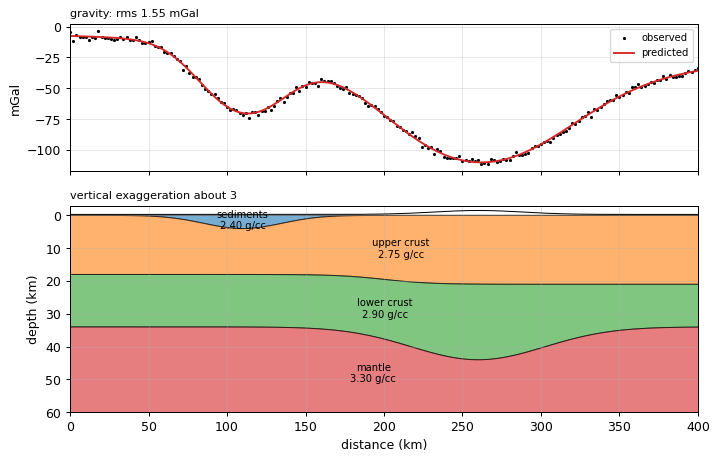

In [4]:
def smooth_step(x, x0, width):
    return 0.5 * (1 + np.tanh((x - x0) / width))

elev = 300.0 + 1200.0 * np.exp(-((x - 260e3) / 40e3) ** 2)      # m above datum
basin_base = 4000.0 * np.exp(-((x - 110e3) / 35e3) ** 2)         # sediment thickness, m
mid_crust = 18e3 + 3e3 * smooth_step(x, 200e3, 30e3)             # upper / lower crust boundary
moho = 34e3 + 10e3 * np.exp(-((x - 260e3) / 60e3) ** 2)          # crustal root under the range

def crust(basin_base, mid_crust, moho, rho_lower=2900.0):
    return [
        model2d.layer(x, 0.0, basin_base, density=2400.0, reference_density=REF, name="sediments"),
        model2d.layer(x, basin_base, mid_crust, density=2750.0, reference_density=REF, name="upper crust"),
        model2d.layer(x, mid_crust, moho, density=rho_lower, reference_density=REF, name="lower crust"),
        model2d.layer(x, moho, 120e3, density=3300.0, reference_density=REF, name="mantle"),
    ]

true_layers = crust(basin_base, mid_crust, moho)
z_obs = -elev
g_true = model2d.gravity(true_layers, x, z_obs=z_obs)
rng = np.random.default_rng(3)
observed = g_true - g_true.mean() - 60.0 + rng.normal(0, 1.5, x.size)   # arbitrary level plus 1.5 mGal noise

reg = model2d.regional(x, observed - g_true, order=0)                   # DC shift only
fig, axes = model2d.plot_model(x, {"gravity": observed}, {"gravity": g_true + reg}, true_layers, z_obs=z_obs,
                               regional_part={"gravity": reg}, depth_max=60e3)
axes[-1].set_title("vertical exaggeration about 3", loc="left", fontsize=9)

## Which layer makes which part of the curve

Each layer's own contribution, with its constant removed. The Moho
relief carries the 100 km wavelength high under the range; the basin is
the sharp low; the mid-crustal step is a gentle ramp.

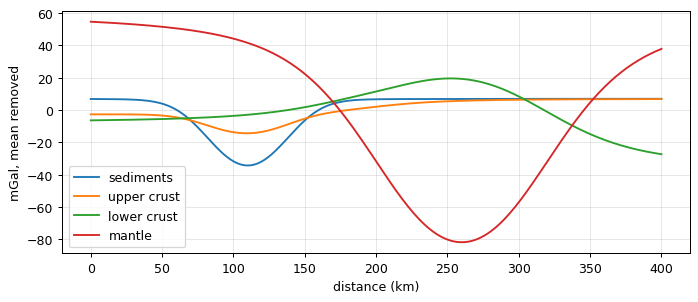

In [5]:
fig, ax = plt.subplots(figsize=(9, 3.5))
for lay in true_layers:
    g = model2d.gravity([lay], x, z_obs=z_obs)
    ax.plot(x / 1e3, g - g.mean(), label=lay.name)
ax.set_xlabel("distance (km)"); ax.set_ylabel("mGal, mean removed"); ax.grid(alpha=0.3); ax.legend()

## Fit the Moho

Keep sediments, upper crust and densities fixed; solve for Moho depth at
nine nodes 50 km apart, interpolated linearly between them, plus the DC
shift. Then repeat with the lower crust 0.05 g/cc too light and watch the
recovered Moho sink to compensate. Both fits reach the noise level.

rms: correct density 1.52 mGal, lower crust 0.05 g/cc light 1.52 mGal (noise 1.5)
mean Moho shift from a 0.05 g/cc density error: +0.9 km


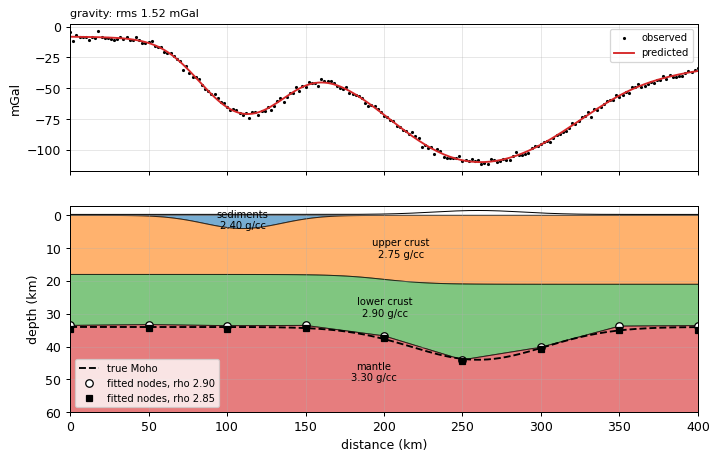

In [6]:
nodes = np.arange(0.0, 400e3 + 1, 50e3)

def build_moho(p, rho_lower=2900.0):
    m = np.interp(x, nodes, p)
    return crust(basin_base, mid_crust, m, rho_lower)

p0 = np.full(nodes.size, 36e3)
res = model2d.fit(x, observed, build_moho, p0, field_name="gravity", bounds=(25e3, 55e3), regional_order=0, z_obs=z_obs)
res_light = model2d.fit(x, observed, lambda p: build_moho(p, 2850.0), p0, field_name="gravity",
                        bounds=(25e3, 55e3), regional_order=0, z_obs=z_obs)
print(f"rms: correct density {res.rms:.2f} mGal, lower crust 0.05 g/cc light {res_light.rms:.2f} mGal (noise 1.5)")

fig, axes = model2d.plot_model(x, {"gravity": observed}, {"gravity": res.predicted}, res.bodies, z_obs=z_obs,
                               regional_part={"gravity": res.regional}, depth_max=60e3)
sec = axes[-1]
sec.plot(x / 1e3, moho / 1e3, "k--", lw=1.5, label="true Moho")
sec.plot(nodes / 1e3, res.params / 1e3, "wo", mec="k", ms=6, label="fitted nodes, rho 2.90")
sec.plot(nodes / 1e3, res_light.params / 1e3, "ks", ms=5, label="fitted nodes, rho 2.85")
sec.legend(loc="lower left", fontsize=8)
print("mean Moho shift from a 0.05 g/cc density error:", f"{(res_light.params - res.params).mean() / 1e3:+.1f} km")

## Basin depth from real gravity

The east-west line from notebook 08 across the Frome Embayment, asking
how thick the cover would have to be to make the gravity low, with
sediments 0.35 g/cc lighter than basement. A trend through the two ends
of the profile is removed first so the residual is zero at both ends,
and no regional is fitted: with a free constant, a uniform layer and the
constant are interchangeable and the fit has no unique answer (a free
tilt is worse, it lets the nodes and the regional trade against each
other and produces kilometres of cover at the profile edge). Basement
depth is solved at nodes every 5 km, constrained to be non-negative.

Only the low can be explained this way. The eastern high needs the dense
basement body of notebook 08, and a low-density granite would explain the
low as well as thick cover does. Depth-to-basement drilling or the SA
cover thickness model decides between them.

rms 1.52 mGal, thickest cover 374 m at 20 km


Text(0, 0.5, 'mGal, end trend removed')

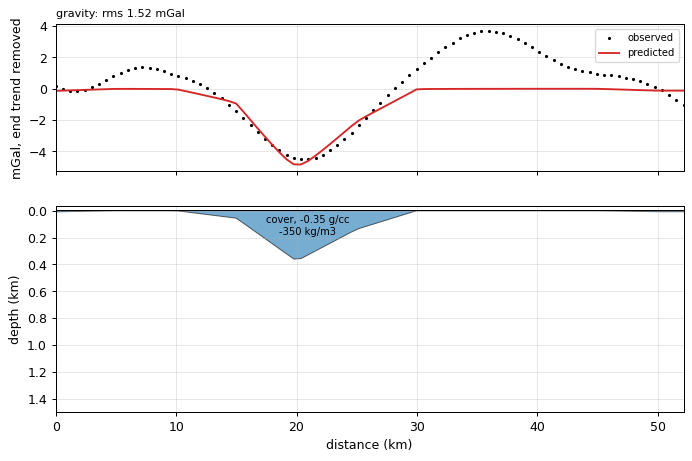

In [7]:
grav = read_grid(f"{DATA}/frome_grav.ers", units="mGal")
line = ((139.35, -30.95), (139.90, -30.95))
pg = grav.profile(*line, epsg=4283)
xg, og = pg.distance[::3], pg.values[::3]                     # one sample per 600 m
ends_x = np.array([xg[:8].mean(), xg[-8:].mean()])
ends_g = np.array([og[:8].mean(), og[-8:].mean()])
resid = og - np.interp(xg, ends_x, ends_g)
bnodes = np.arange(0.0, xg[-1] + 1, 5e3)

def build_basin(p):
    return [model2d.layer(xg, 0.0, np.interp(xg, bnodes, p), density=-350.0, name="cover, -0.35 g/cc")]

resb = model2d.fit(xg, resid, build_basin, np.full(bnodes.size, 200.0), field_name="gravity",
                   bounds=(0.0, 2000.0), regional_order=None, z_obs=-1.0)
print(f"rms {resb.rms:.2f} mGal, thickest cover {resb.params.max():.0f} m at {bnodes[np.argmax(resb.params)] / 1e3:.0f} km")
fig, axes = model2d.plot_model(xg, {"gravity": resid}, {"gravity": resb.predicted}, resb.bodies, z_obs=-1.0,
                               depth_max=max(1500.0, 1.3 * resb.params.max()))
axes[0].set_ylabel("mGal, end trend removed")

To use this on a real regional section: sample each horizon along the
profile as an array on x (digitised seismic interfaces, a Moho grid, well
tops), build the layers with `layer`, decide which nodes are free, and
call `fit`. Anything not fixed by other data will trade against density.